In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import imageio
import glob
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio
from rasterio.mask import mask
from datetime import datetime
import os
import collections
import shapely
import pyproj
from rasterstats import zonal_stats, gen_zonal_stats
import rasterstats
import utils

from tqdm.notebook import tqdm
tqdm.pandas()

In [ ]:
tif_files = sorted(glob.glob(os.path.join(utils.in_data_dir, "combined_drought_indicator_2012-2025")))

<Axes: >

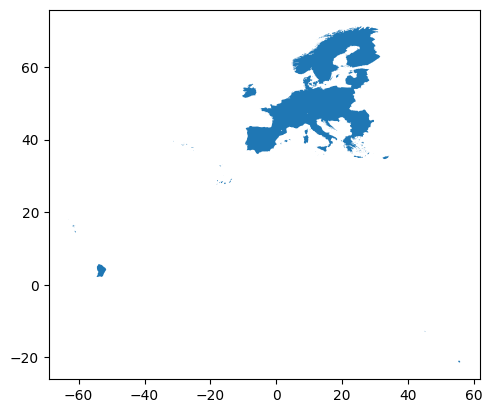

In [39]:
eu_mask = gpd.read_file("CNTR_RG_10M_2024_4326.shp")
eu_mask = eu_mask[(eu_mask["EU_STAT"] == "T") | eu_mask["CNTR_ID"].isin(["NO", "CH"])] # EU + Norway and Switzerland
eu_mask = eu_mask.dissolve()
eu_mask.geometry.plot()

In [ ]:
water_val = 0
default_val = 1
warning_val = 2
drought_val = 3

drought_index_mapper= np.array(
    [
        default_val,  # no drought -> grey
        default_val,  # watch = yellow
        warning_val,  # warning = orange
        drought_val,  # alert = red
        default_val,  # recovery = bright purple
        default_val,  # temporary soil moisture recovery = dark purple
        default_val,  # temporary vegetation recovery = green
        default_val,  # placeholder - unused so far
        water_val,  # water body - blue
    ],
    dtype=np.uint8,
)   

In [41]:
def date_from_filename(filename):
    date_str = filename.split("_")[3]
    date = datetime.strptime(date_str, "%Y%m%d")
    return date

[11.  0.  0.  9. 10. 10. 11. 10. 10. 10. 10. 10. 11. 10. 10. 10. 10. 10.
 11. 10. 10. 11. 10. 10. 10. 10. 10. 11. 10. 10. 10.  0.  0.  0.]


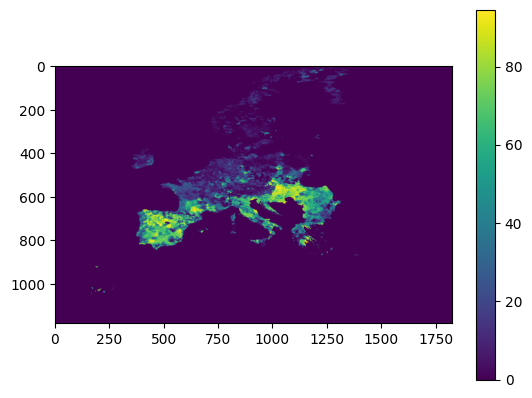

In [86]:

yearly_data = []




for dir in sorted(glob.glob("drought_data/*")):
    if dir.endswith(".zip"):
        continue
    
    masked_frames = []

    files = sorted(glob.glob(os.path.join(dir, "*")))
    files = [file for file in files if file.endswith(".tif")]
    for i, file in enumerate(files):
        with rasterio.open(file) as src:
            
            im_masked, transform = mask(
                    src,
                    eu_mask.geometry,
                    all_touched=True,
                    crop=True,
                    pad=True, # TODO: recheck the parametrization on this function call!
                    nodata=-1 # we pretend that any pixel that is not in the EU mask is covered by water
                    ) # remove coordinate transformation info
        
        im_masked = im_masked[0]
        im_masked = drought_index_mapper[im_masked]

        im_masked = (im_masked > 1).astype(float)
        
        cur_date = date_from_filename(os.path.basename(file))
        if (i + 1) < len(files):
            next_date = date_from_filename(os.path.basename(files[i+1]))
        else: 
            next_date = datetime.fromisocalendar(cur_date.year + 1, 1, 1)               
        delta_t = next_date - cur_date
        
        im_masked *= delta_t.days


        
        
        masked_frames.append(im_masked)

    frames_ar = np.array(masked_frames)
    print(frames_ar[:,600,1000])
    
    frames_ar = frames_ar.sum(axis=0).astype(np.float64)
    frames_ar *= 100 / 365.0 # go from total number of 
    
    yearly_data = frames_ar
    fig, ax = plt.subplots()
    im = ax.imshow(frames_ar)

    fig.colorbar(im, ax=ax)
    plt.show()
    break
    


In [78]:
lau_df = gpd.read_file("LAU_RG_01M_2024_4326.shp")

In [85]:
assert( lau_df.crs == crs)
print(crs)

EPSG:4326


In [79]:
lau_df

,GISCO_ID,CNTR_CODE,LAU_NAME,POP_2024,POP_DENS_2,AREA_KM2,YEAR,geometry
0,AL_AL141,AL,Kurbin,0.0,NaN,269.178779,2024,"POLYGON ((19.55733 41.57767, 19.57182 41.59103..."
1,AL_AL142,AL,Lezhë,0.0,NaN,509.342849,2024,"POLYGON ((19.8671 41.95292, 19.8707 41.94779, ..."
2,AL_AL143,AL,Mirditë,0.0,NaN,870.249553,2024,"POLYGON ((19.8671 41.95292, 19.87091 41.9601, ..."
3,AL_AL151,AL,Fushë Arrës,0.0,NaN,540.797778,2024,"POLYGON ((20.21865 42.19467, 20.22878 42.18531..."
4,AL_AL152,AL,Malësi e Madhe,0.0,NaN,951.441628,2024,"POLYGON ((19.78771 42.48755, 19.77704 42.47615..."
...,...,...,...,...,...,...,...,...
97982,SK_526410,SK,Brutovce,146.0,NaN,13.689842,2024,"POLYGON ((20.82975 49.07737, 20.82735 49.07437..."
97983,SK_526428,SK,Buglovce,265.0,NaN,3.034235,2024,"POLYGON ((20.71104 48.98195, 20.69446 48.9754,..."
97984,SK_526436,SK,Bystrany,3997.0,NaN,7.828098,2024,"POLYGON ((20.76609 48.96604, 20.772 48.95674, ..."
97985,SK_526444,SK,Danišovce,563.0,NaN,4.307463,2024,"POLYGON ((20.6323 48.95224, 20.63104 48.94703,..."


In [93]:
stats = gen_zonal_stats(
    lau_df,
    yearly_data,
    affine=transform,
    stats = ["mean", "sum"],
    nodata = water_val,
    geojson_out=True  
)

In [94]:
nuts_stats = gpd.GeoDataFrame.from_features(stats)

In [95]:
nuts_stats

,geometry,GISCO_ID,CNTR_CODE,LAU_NAME,POP_2024,POP_DENS_2,AREA_KM2,YEAR,mean,sum
0,"POLYGON ((19.55733 41.57767, 19.57182 41.59103...",AL_AL141,AL,Kurbin,0.0,None,269.178779,2024,NaN,NaN
1,"POLYGON ((19.8671 41.95292, 19.8707 41.94779, ...",AL_AL142,AL,Lezhë,0.0,None,509.342849,2024,NaN,NaN
2,"POLYGON ((19.8671 41.95292, 19.87091 41.9601, ...",AL_AL143,AL,Mirditë,0.0,None,870.249553,2024,NaN,NaN
3,"POLYGON ((20.21865 42.19467, 20.22878 42.18531...",AL_AL151,AL,Fushë Arrës,0.0,None,540.797778,2024,NaN,NaN
4,"POLYGON ((19.78771 42.48755, 19.77704 42.47615...",AL_AL152,AL,Malësi e Madhe,0.0,None,951.441628,2024,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
97982,"POLYGON ((20.82975 49.07737, 20.82735 49.07437...",SK_526410,SK,Brutovce,146.0,None,13.689842,2024,10.958904,10.958904
97983,"POLYGON ((20.71104 48.98195, 20.69446 48.9754,...",SK_526428,SK,Buglovce,265.0,None,3.034235,2024,2.739726,2.739726
97984,"POLYGON ((20.76609 48.96604, 20.772 48.95674, ...",SK_526436,SK,Bystrany,3997.0,None,7.828098,2024,NaN,NaN
97985,"POLYGON ((20.6323 48.95224, 20.63104 48.94703,...",SK_526444,SK,Danišovce,563.0,None,4.307463,2024,NaN,NaN


<Axes: >

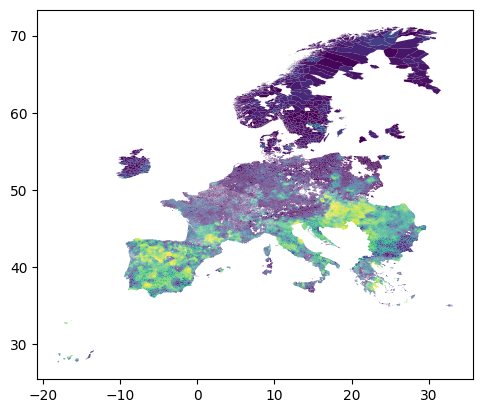

In [98]:
nuts_stats.plot("mean")

In [110]:
rows, cols = np.indices(yearly_data.shape)
xs, ys = rasterio.transform.xy(transform, rows, cols)

points = gpd.GeoDataFrame(
    {"value": yearly_data.flatten()},
    geometry=gpd.points_from_xy(np.array(xs).flatten(),
                                np.array(ys).flatten()),
    crs=crs
).to_crs(epsg=3857)

In [111]:
intersection = gpd.overlay(points, lau_df.to_crs(epsg=3857), how="intersection")

intersection["area_weight"] = (
    intersection.geometry.area /
    points.loc[intersection.index, "geometry"].area.values
)

In [113]:
intersection

,value,GISCO_ID,CNTR_CODE,LAU_NAME,POP_2024,POP_DENS_2,AREA_KM2,YEAR,geometry,area_weight
0,0.000000,NO_5620,NO,Nordkapp,2951.0,NaN,926.431805,2024,POINT (2845604.483 11452321.307),NaN
1,5.753425,NO_5620,NO,Nordkapp,2951.0,NaN,926.431805,2024,POINT (2850242.796 11452321.307),NaN
2,5.753425,NO_5620,NO,Nordkapp,2951.0,NaN,926.431805,2024,POINT (2854881.108 11452321.307),NaN
3,8.493151,NO_5620,NO,Nordkapp,2951.0,NaN,926.431805,2024,POINT (2859519.42 11452321.307),NaN
4,8.493151,NO_5620,NO,Nordkapp,2951.0,NaN,926.431805,2024,POINT (2864157.732 11452321.307),NaN
...,...,...,...,...,...,...,...,...,...,...
368588,36.164384,ES_38901,ES,"Pinar de El Hierro, El",0.0,NaN,83.280317,2024,POINT (-2001431.678 3214870.614),NaN
368589,44.383562,ES_38048,ES,Valverde,0.0,NaN,103.420316,2024,POINT (-1996793.366 3214870.614),NaN
368590,36.164384,ES_38901,ES,"Pinar de El Hierro, El",0.0,NaN,83.280317,2024,POINT (-2006069.99 3209631.514),NaN
368591,47.123288,ES_38901,ES,"Pinar de El Hierro, El",0.0,NaN,83.280317,2024,POINT (-2001431.678 3209631.514),NaN


In [115]:
nuts_summary = (
    intersection
    .groupby("GISCO_ID")
    .agg({"area_weight": "sum"})
    .reset_index()
)

lau_df = lau_df.merge(nuts_summary, on="GISCO_ID", how="left")

<Axes: >

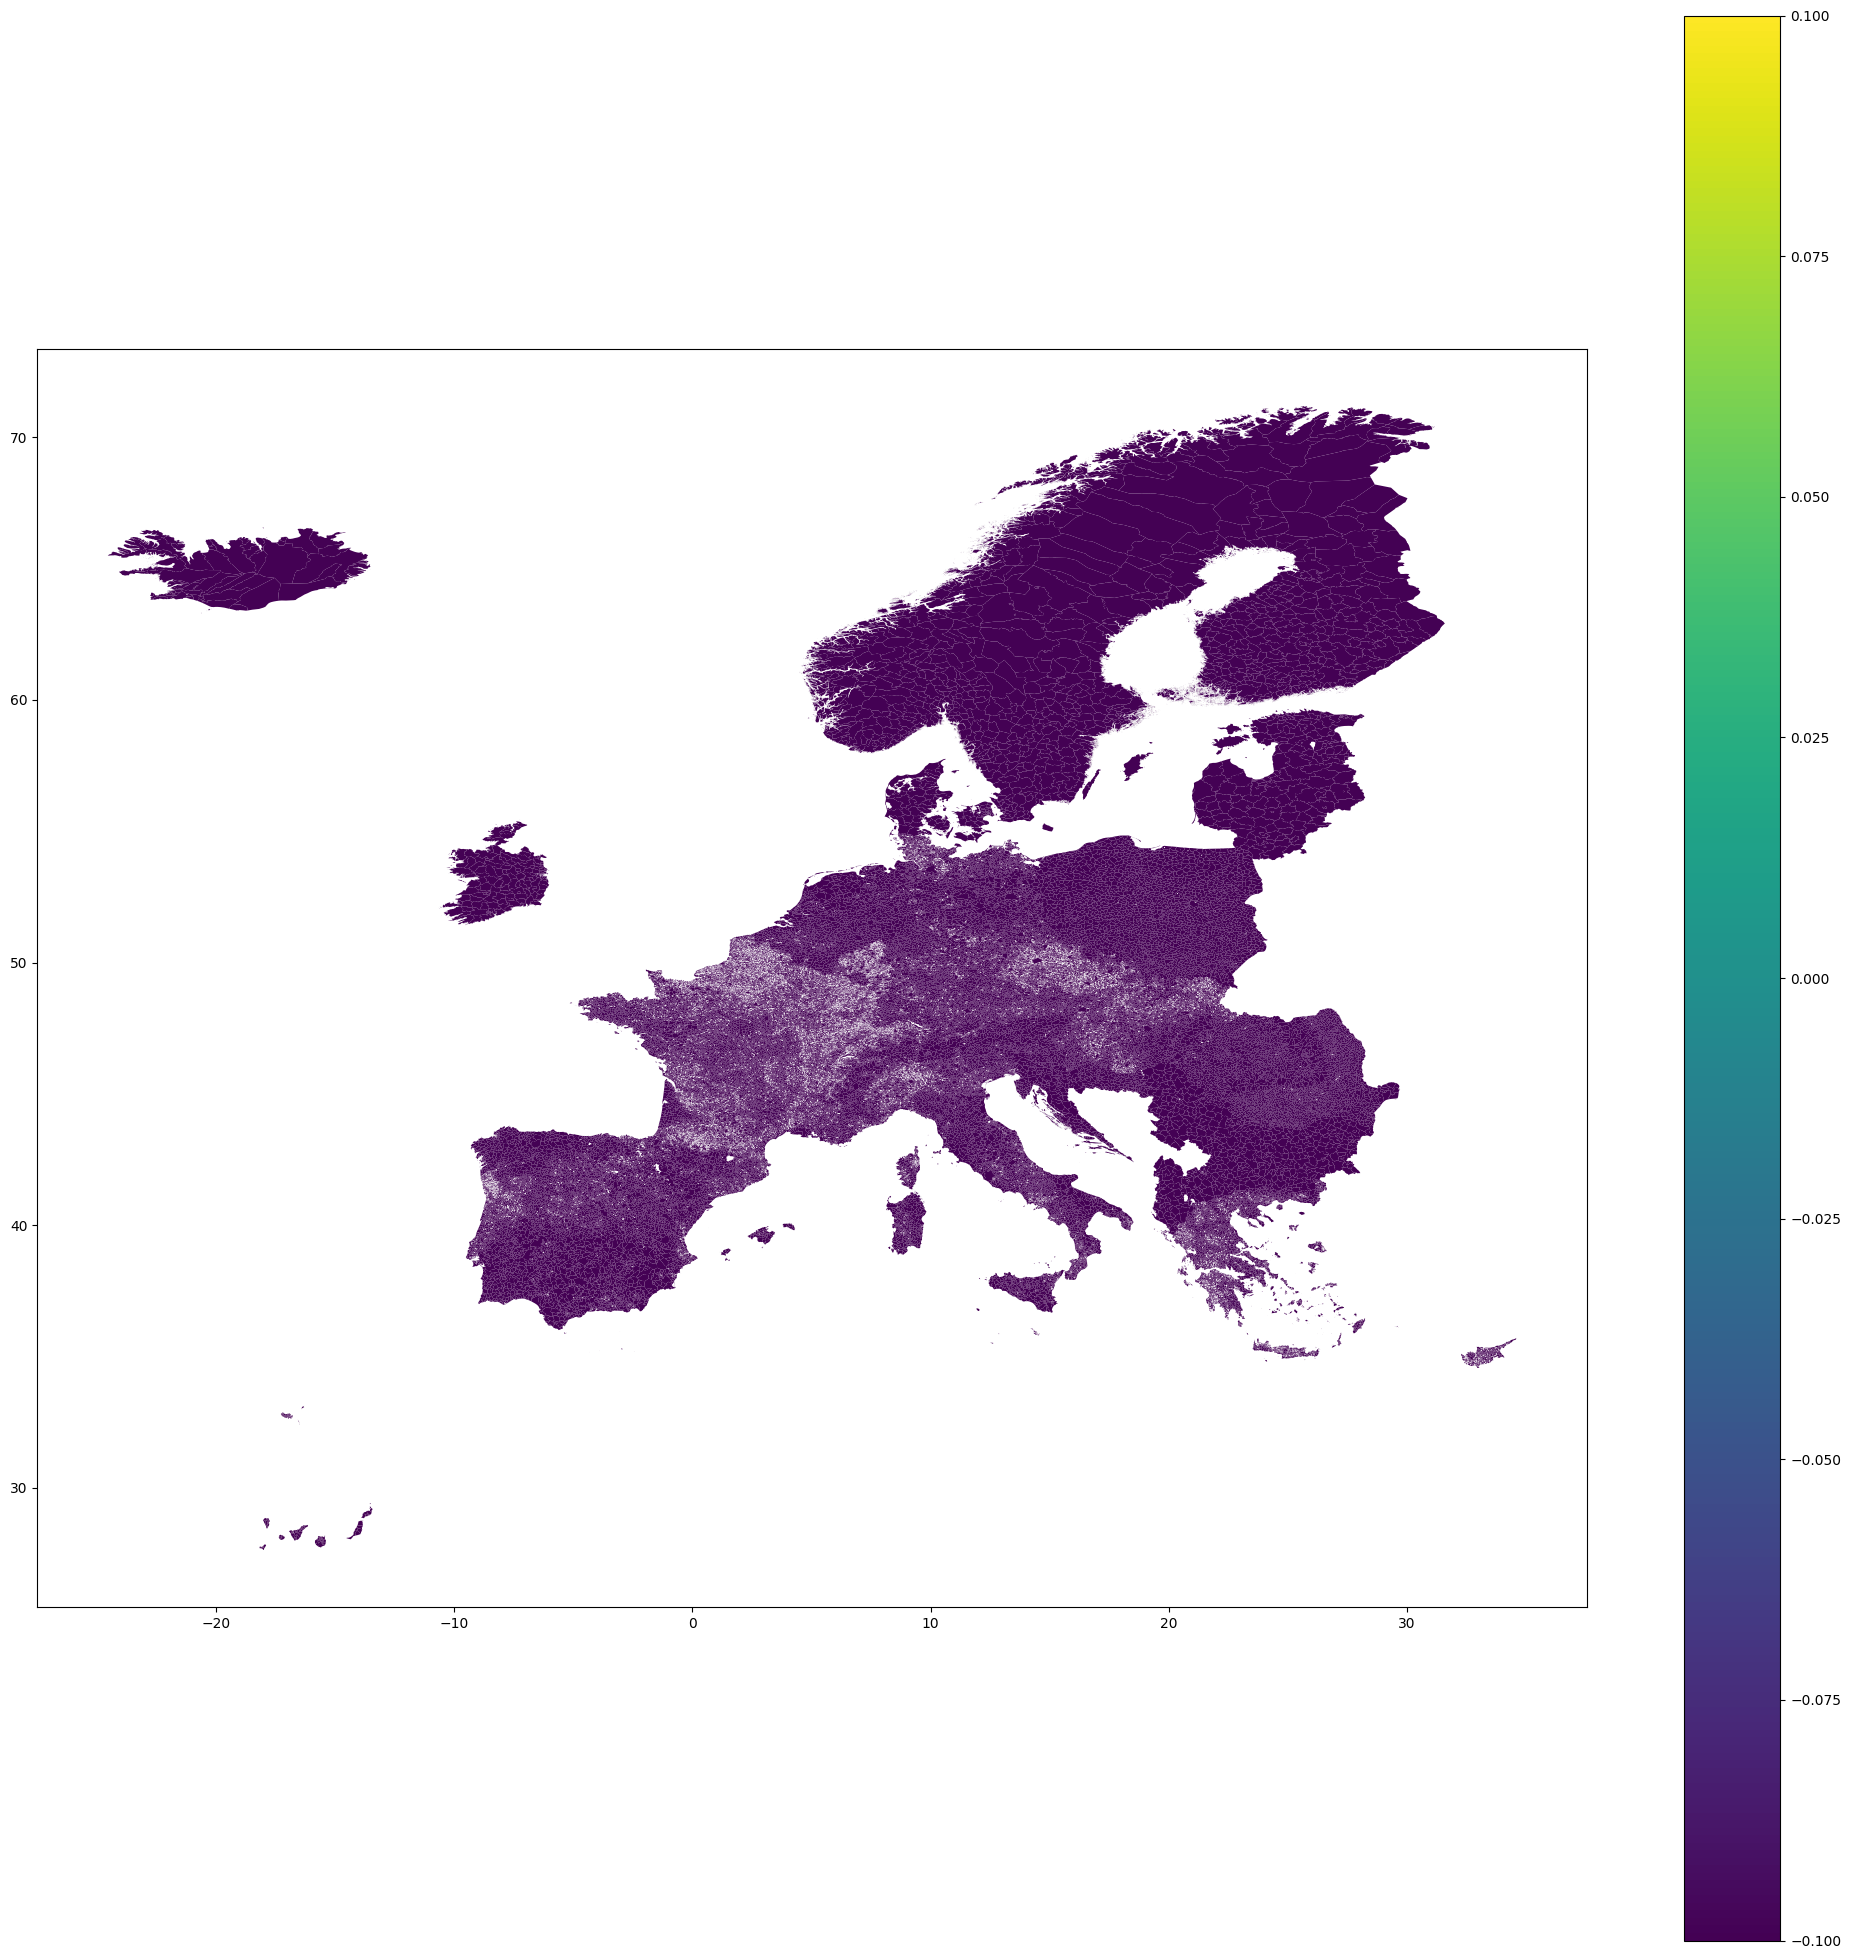

In [118]:
lau_df.plot(    column="area_weight",
    legend=True,
    cmap="viridis",
    figsize=(25,25))

In [119]:
ger_df = lau_df[lau_df["CNTR_CODE"] == "DE"]

<Axes: >

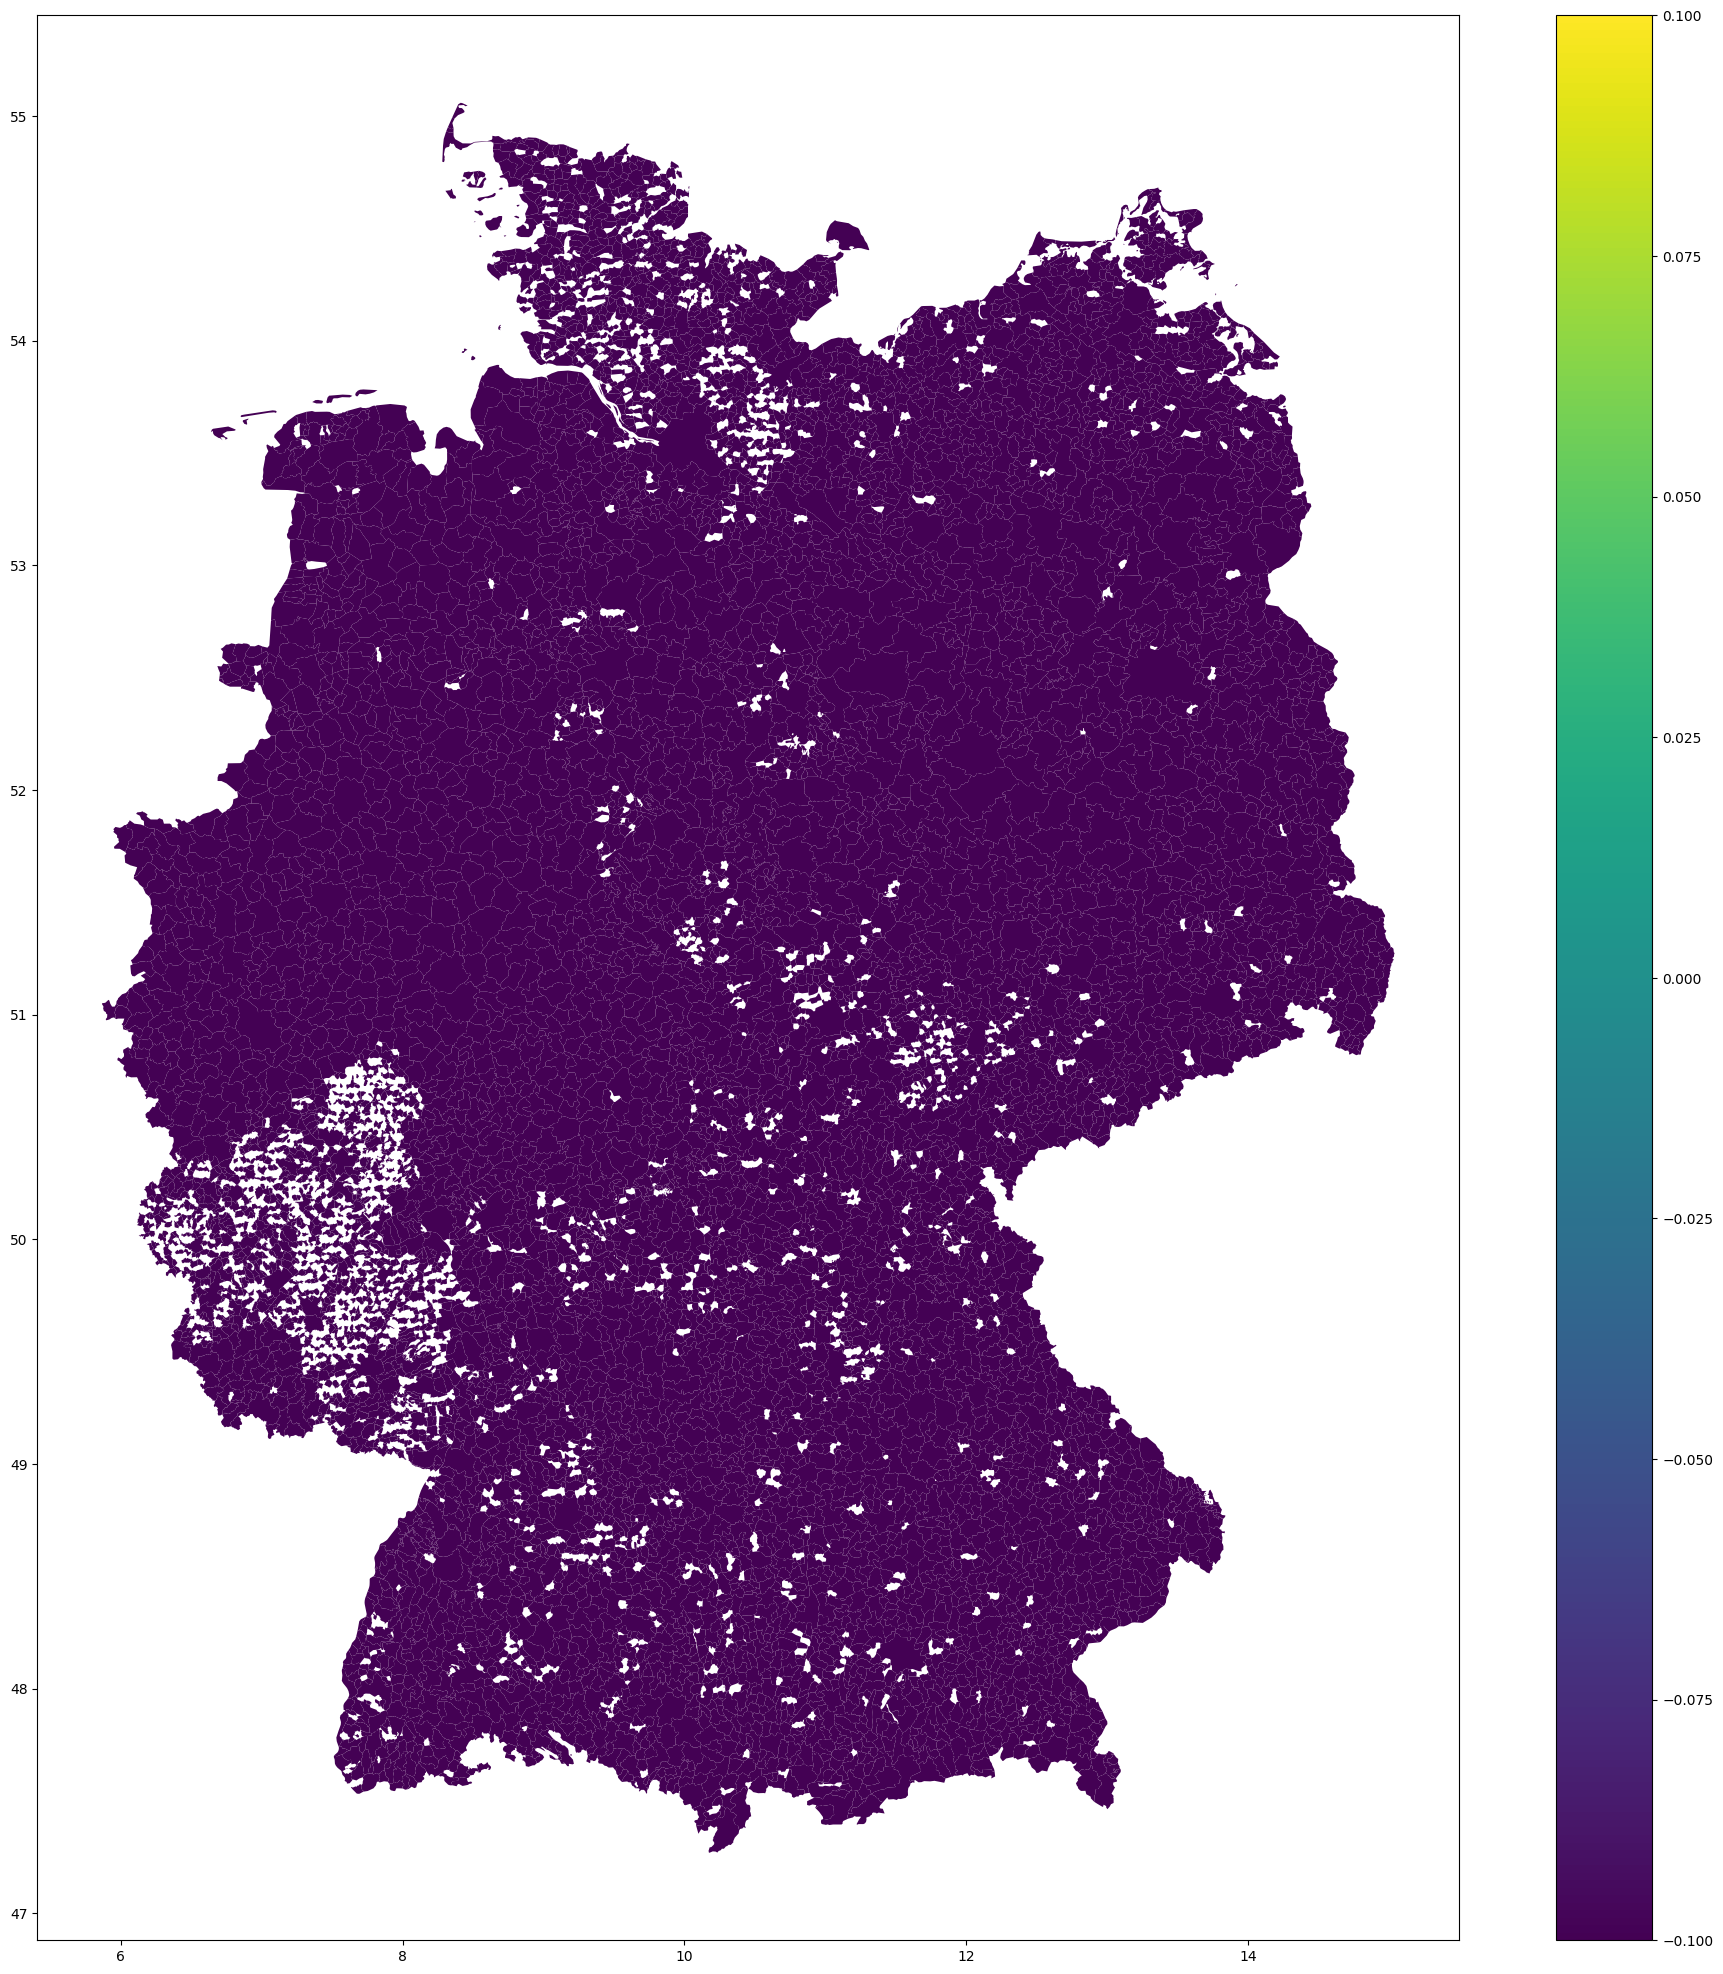

In [120]:
ger_df.plot(   column="area_weight",
    legend=True,
    cmap="viridis",
    figsize=(25,25))

In [121]:
with rasterio.open(tif_files[0]) as src:
    raster = src.read(1)          # first band as numpy array
    transform = src.transform     # affine transform
    crs = src.crs                 # coordinate reference system
    nodata = src.nodata

In [125]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.transform import Affine
from shapely.geometry import box
from shapely.ops import unary_union

def pixel_bounds(transform, row, col):
    x0, y0 = transform * (col, row)
    x1, y1 = transform * (col+1, row+1)
    # transform may have negative y scale; build box robustly
    return box(min(x0,x1), min(y0,y1), max(x0,x1), max(y0,y1))

def area_weighted_stats_for_polygon(raster, transform, polygon, nodata=None):
    # raster: 2D numpy array (rows, cols)
    # transform: affine transform for raster
    # polygon: shapely geometry in same CRS as raster
    rows, cols = raster.shape
    # compute pixel window covering polygon
    minx, miny, maxx, maxy = polygon.bounds
    # convert bounds to row/col indices
    col_min, row_max = ~transform * (minx, miny)
    col_max, row_min = ~transform * (maxx, maxy)
    # clamp to raster
    row0 = max(0, int(np.floor(row_min)))
    row1 = min(rows-1, int(np.ceil(row_max)))
    col0 = max(0, int(np.floor(col_min)))
    col1 = min(cols-1, int(np.ceil(col_max)))

    pixel_area = abs(transform.a * transform.e)  # pixel width * height (signed)
    weighted_sum = 0.0
    weight_total = 0.0

    for r in range(row0, row1+1):
        for c in range(col0, col1+1):
            val = raster[r, c]
            if nodata is not None and val == nodata:
                continue
            pb = pixel_bounds(transform, r, c)
            inter = polygon.intersection(pb)
            if not inter.is_empty:
                w = inter.area / pixel_area
                weighted_sum += float(val) * w
                weight_total += w

    return (weighted_sum / weight_total) if weight_total > 0 else np.nan


gdf = gpd.read_file("LAU_RG_01M_2024_4326.shp").to_crs(src.crs)





In [131]:
gdf["watch_warn_perc"] = gdf["geometry"].apply(lambda row: area_weighted_stats_for_polygon(yearly_data, transform, row, nodata=src.nodata))


In [124]:
results

[{'weighted_sum': 35.11492458758599,
  'weight_total': 16.762122140965193,
  'weighted_mean': 2.094897310273627},
 {'weighted_sum': 67.6410190783105,
  'weight_total': 31.944316636511672,
  'weighted_mean': 2.117466460403109},
 {'weighted_sum': 91.57893346917537,
  'weight_total': 54.37245497869387,
  'weighted_mean': 1.6842891038313619},
 {'weighted_sum': 44.74348927844702,
  'weight_total': 34.05309138050156,
  'weighted_mean': 1.3139332572920728},
 {'weighted_sum': 85.69407990374316,
  'weight_total': 59.93493568459777,
  'weighted_mean': 1.429785131575023},
 {'weighted_sum': 49.99700870879005,
  'weight_total': 31.595871777439307,
  'weighted_mean': 1.5823905433269252},
 {'weighted_sum': 92.08372179397516,
  'weight_total': 54.98180891341828,
  'weighted_mean': 1.6748034234192353},
 {'weighted_sum': 58.29362501093316,
  'weight_total': 31.171171980723734,
  'weighted_mean': 1.8701133549608582},
 {'weighted_sum': 24.23855565400308,
  'weight_total': 12.11927782700154,
  'weighted_me